# 1. Install Libraries

In [1]:
!pip install --force-reinstall numpy==1.26.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 57.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
music21 9.9.2 requires numpy>=1.26.4, but you have nump

In [1]:
!pip install spectral mrmr_selection mealpy openpyxl scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.8/168.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.3/423.3 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 7.6 MB/s eta 0:00:00


# 2. Import Libraries

In [1]:
import spectral
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import os
import pandas as pd
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix
from mrmr import mrmr_classif
from mealpy import FloatVar, PSO, GWO, MFO
from mealpy.evolutionary_based import GA

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


# 3. Data Loading Function & Config

In [159]:
def loadData(name):
    data_path = "..\\data"  # আপনার ডেটা ফোল্ডার
    if name == 'IP':
        data   = sio.loadmat(os.path.join(data_path, 'Indian_pines.mat'))['indian_pines_corrected']
        labels = sio.loadmat(os.path.join(data_path, 'Indian_pines_gt.mat'))['indian_pines_gt']
    elif name == 'SA':
        data   = sio.loadmat(os.path.join(data_path, 'Salinas.mat'))['salinas']
        labels = sio.loadmat(os.path.join(data_path, 'Salinas_gt.mat'))['salinas_gt']
    elif name == 'PU':
        data   = sio.loadmat(os.path.join(data_path, 'PaviaU.mat'))['paviaU']
        labels = sio.loadmat(os.path.join(data_path, 'PaviaU_gt.mat'))['paviaU_gt']
    else:
        raise ValueError("Dataset must be 'IP', 'PU', or 'SA'")
    return data, labels

dataset    = 'IP'    # 'IP', 'PU', or 'SA'
K          = 2       # features per segment
META_METHODS = ['PSO', 'GWO', 'MFO', 'GA']
META_EPOCH = 5
META_POP   = 20

X, y = loadData(dataset)
print(f'Data shape: {X.shape}, GT shape: {y.shape}')

Data shape: (145, 145, 200), GT shape: (145, 145)


# Step 1: Band Segmentation (Based on paper 3 - Tanver Ahmed)

In [143]:
if dataset == 'IP':
    regions = [X[:, :, 0:36], X[:, :, 36:102], X[:, :, 102:200]]
elif dataset == 'PU':
    regions = [X[:, :, 0:37], X[:, :, 37:72], X[:, :, 72:103]]
elif dataset == 'SA':
    regions = [X[:, :, 0:36], X[:, :, 36:81], X[:, :, 81:106], X[:, :, 106:204]]

print("Regions created:")
for i, r in enumerate(regions): print(f' Region {i+1}: {r.shape}')

Regions created:
 Region 1: (610, 340, 37)
 Region 2: (610, 340, 35)
 Region 3: (610, 340, 31)


# 4. Core Helper Functions (Fixed)

In [145]:
def applyMRMR(X, y, K):
    from mrmr import mrmr_classif
    import pandas as pd
    # Filter out unlabeled pixels (label 0)
    mask = y > 0
    X_q = X[mask]                       # (num_valid_pixels, bands)
    y_q = y[mask] - 1                   # zero-indexed labels
    X_df = pd.DataFrame(X_q)
    y_sr = pd.Series(y_q)
    selected_features = mrmr_classif(X_df, y_sr, K, show_progress=False)
    return list(selected_features)

def applyPCA(X, numComponents=75, random_state=345):
    newX = np.reshape(X, (-1, X.shape[2]))
    pca = PCA(n_components=numComponents, random_state=random_state)
    newX = pca.fit_transform(newX)
    scaler = MinMaxScaler().fit(newX)
    newX = scaler.transform(newX)
    newX = np.reshape(newX, (X.shape[0], X.shape[1], numComponents))
    return newX, pca

def padWithZeros(X, margin=2):
    newX = np.zeros((X.shape[0] + 2*margin, X.shape[1] + 2*margin, X.shape[2]))
    newX[margin:X.shape[0]+margin, margin:X.shape[1]+margin, :] = X
    return newX

def createImageCubes(X, y, windowSize=25, removeZeroLabels=True):
    margin = int((windowSize - 1) / 2)
    zeroPaddedX = padWithZeros(X, margin=margin)
    patchesData = np.zeros((X.shape[0]*X.shape[1], windowSize, windowSize, X.shape[2]))
    patchesLabels = np.zeros((X.shape[0]*X.shape[1]))
    patchIndex = 0
    for r in range(margin, zeroPaddedX.shape[0]-margin):
        for c in range(margin, zeroPaddedX.shape[1]-margin):
            patch = zeroPaddedX[r-margin:r+margin+1, c-margin:c+margin+1]
            patchesData[patchIndex] = patch
            patchesLabels[patchIndex] = y[r-margin, c-margin]
            patchIndex += 1
    if removeZeroLabels:
        patchesData = patchesData[patchesLabels > 0]
        patchesLabels = patchesLabels[patchesLabels > 0]
        patchesLabels -= 1
    return patchesData, patchesLabels

def calculate_AA(y_true, y_pred):
    """
    Confusion Matrix থেকে প্রতিটি ক্লাসের Accuracy বের করে তার গড় (AA) রিটার্ন করে।
    """
    cm = confusion_matrix(y_true, y_pred)
    # প্রতিটি ক্লাসের জন্য Accuracy = diagonal_sum / row_sum (যদি row_sum > 0 হয়)
    each_class_acc = np.diag(cm) / np.sum(cm, axis=1)
    # NaN (যেখানে row_sum 0) বাদ দিয়ে গড় নেওয়া
    return np.nanmean(each_class_acc)


# STEP 2: Metaheuristics + Dynamic ML Fitness

In [146]:

mask = y > 0
y_all = y[mask] - 1
META_METHODS = ['PSO', 'GWO', 'MFO', 'GA']
META_EPOCH = 5
META_POP = 20

TARGET_CLF_FOR_OPTIMIZATION = 'ExtraTrees'

def get_classifier(name):
    if name == 'SVM': return SVC(kernel='rbf')
    if name == 'KNN': return KNeighborsClassifier(n_neighbors=5)
    if name == 'RF': return RandomForestClassifier(n_estimators=20, random_state=42) # Lightweight for optimizer
    if name == 'ExtraTrees': return ExtraTreesClassifier(n_estimators=20, random_state=42)
    raise ValueError("Unknown classifier name")

def optimize_group(seg_data, method='PSO'):
    n_feat = seg_data.shape[2]
    X_flat = seg_data[mask]
    X_tr, _, y_tr, _ = train_test_split(X_flat, y_all, test_size=0.5, random_state=345, stratify=y_all)
    if X_tr.shape[0] > 5000:
        idx = np.random.choice(X_tr.shape[0], 5000, replace=False)
        X_tr, y_tr = X_tr[idx], y_tr[idx]
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)

    def fitness(sol):
        binary = (np.array(sol) > 0.5).astype(int)
        n = int(np.sum(binary))
        if n < 2: return 0.0
        sel = np.where(binary == 1)[0]

        # === DYNAMIC CLASSIFIER LOADING ===
        clf = get_classifier(TARGET_CLF_FOR_OPTIMIZATION)
        # ==================================

        scores = cross_val_score(clf, X_tr[:, sel], y_tr, cv=5, scoring='accuracy', n_jobs=-1)
        return scores.mean() - (0.01 * n)

    problem = {
        'obj_func': lambda s: -fitness(s),
        'bounds': FloatVar(lb=[0]*n_feat, ub=[1]*n_feat),
        'minmax': 'min', 'log_to': None
    }
    optimizers = {'PSO': PSO.OriginalPSO, 'GWO': GWO.OriginalGWO, 'MFO': MFO.OriginalMFO, 'GA': GA.BaseGA}
    opt = optimizers[method](epoch=META_EPOCH, pop_size=META_POP)
    opt.solve(problem)

    best = opt.g_best.solution
    best_bin = (np.array(best) > 0.5).astype(int)
    sel_idx = np.where(best_bin == 1)[0]
    print(f'  {method} selected {len(sel_idx)} features -> indices {sel_idx}')
    return seg_data[:, :, sel_idx]

# STEPS 2-3: Run Optimization & Concatenate

In [66]:
all_results = {}
for method in META_METHODS:
    print(f'\n=== Running {method} (Optimizing for {TARGET_CLF_FOR_OPTIMIZATION}) ===')
    selected = [optimize_group(reg, method) for reg in regions]
    concat_feats = np.concatenate(selected, axis=2)
    all_results[method] = concat_feats
    print(f'Concatenated shape: {concat_feats.shape}')


=== Running PSO (Optimizing for ExtraTrees) ===
  PSO selected 11 features -> indices [ 2  5  8  9 10 17 19 26 33 34 35]
  PSO selected 18 features -> indices [ 0  4  8  9 13 20 28 30 31 33 35 41 45 46 50 52 53 63]
  PSO selected 27 features -> indices [ 2  7  8  9 10 15 19 27 30 33 34 35 45 52 59 63 64 70 71 79 80 81 82 86
 87 89 90]
Concatenated shape: (145, 145, 56)

=== Running GWO (Optimizing for ExtraTrees) ===
  GWO selected 7 features -> indices [ 0  4 15 22 27 28 35]
  GWO selected 16 features -> indices [ 0  3  8  9 12 13 19 20 31 34 38 40 43 55 61 63]
  GWO selected 29 features -> indices [ 1  5  6 11 14 15 16 18 26 29 34 38 41 45 46 49 55 62 70 72 75 76 77 84
 86 90 91 93 94]
Concatenated shape: (145, 145, 52)

=== Running MFO (Optimizing for ExtraTrees) ===
  MFO selected 5 features -> indices [ 1  4 17 29 34]
  MFO selected 6 features -> indices [ 6  7 19 43 57 59]
  MFO selected 9 features -> indices [ 6 16 33 39 46 48 58 67 81]
Concatenated shape: (145, 145, 20)

=== R

# Step 4: Apply PCA

In [170]:
PCA_COMPONENTS = 1
pca_results = {}
pca_objects = {}
for method, concat in ({"NP":X}).items():
    reduced_cube, pca_obj = applyPCA(concat, numComponents=PCA_COMPONENTS, random_state=345)
    pca_results[method] = reduced_cube
    pca_objects[method] = pca_obj
    print(f'{method} PCA reduced features from {concat.shape[2]} to {PCA_COMPONENTS}')

NP PCA reduced features from 200 to 1


# STEP 5: mRMR Ranking (Toggle ON/OFF) using your applyMRMR

In [171]:
MRMR_ON = False   # True = apply mRMR, False = skip
final_features = {}
xp = {"NP":X}
if MRMR_ON:
    print("\nRunning mRMR on PCA-reduced features...")
    for method, cube in all_results.items():
        k = 15
        ranked_idx = applyMRMR(cube, y, k)
        cube_ranked = cube[:, :, ranked_idx]
        final_features[method] = cube_ranked
        print(f'{method} mRMR ranking complete ({k} features).')
else:
    final_features = pca_results

# STEP 6: Final ML Classification using 25x25 Patches

## New Logic

In [172]:
WINDOW_SIZE = 25
TARGET_CLF_FOR_OPTIMIZATION = 'ExtraTrees'
import time
from sklearn.base import clone
from sklearn.metrics import cohen_kappa_score
from sklearn.pipeline import Pipeline

classifier_mapping = {
    'SVM': SVC(kernel='rbf'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'RF': RandomForestClassifier(n_estimators=100, random_state=42),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=42)
}

if TARGET_CLF_FOR_OPTIMIZATION not in classifier_mapping:
    print(f"Warning: {TARGET_CLF_FOR_OPTIMIZATION} not recognized. Using 'ExtraTrees' instead.")
    TARGET_CLF_FOR_OPTIMIZATION = 'ExtraTrees'

metrics_data = []
for method, cube in final_features.items():
    print(f'\n--- Processing {method} with {WINDOW_SIZE}x{WINDOW_SIZE} Patches ---')
    
    oa_scores = []
    aa_scores = []
    kappa_scores = []
    train_times = []
    test_times = []
    
    if WINDOW_SIZE == 1:
        patches, patch_labels = cube, y # createImageCubes(cube, y, windowSize=WINDOW_SIZE, removeZeroLabels=True)
        X_flat = cube.reshape(-1, cube.shape[2])
        scaler = StandardScaler()
        X_flat = scaler.fit_transform(X_flat)
        patch_labels = patch_labels.reshape(-1)
    else:
        patches, patch_labels = createImageCubes(cube, y, windowSize=WINDOW_SIZE, removeZeroLabels=True)
        X_flat = patches.reshape(patches.shape[0], -1)
        scaler = StandardScaler()
        X_flat = scaler.fit_transform(X_flat)



    X_train, X_test, y_train, y_test = train_test_split(X_flat, patch_labels, test_size=0.5, random_state=42, stratify=patch_labels)
    clf = clone(classifier_mapping[TARGET_CLF_FOR_OPTIMIZATION])
    start_train = time.time()
    clf.fit(X_train, y_train)
    train_times.append(time.time() - start_train)

    start_test = time.time()
    y_pred = clf.predict(X_test)
    test_times.append(time.time() - start_test)

    oa = accuracy_score(y_test, y_pred)
    aa = calculate_AA(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', clone(classifier_mapping[TARGET_CLF_FOR_OPTIMIZATION])),
    ])
    cross_score = cross_val_score(
        pipe, X_flat, patch_labels,
        cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='accuracy',
        n_jobs=-1,
    )
    print(f'CV = {cross_score.mean()*100:.2f}% OA = {oa*100:.2f}%, AA = {aa*100:.2f}%, Kappa = {kappa:.4f}')

    oa_scores.append(oa)
    aa_scores.append(aa)
    kappa_scores.append(kappa)
    mean_train_time = np.mean(train_times)
    mean_test_time = np.mean(test_times)
    metrics_data.append({
        'Metaheuristic': method,
        'Classifier': TARGET_CLF_FOR_OPTIMIZATION,
        'Overall Accuracy (OA %)': f'{oa*100:.2f}',
        'Average Accuracy (AA %)': f'{aa*100:.2f}',
        'Kappa': f'{kappa:.4f}',
        'CV': f'{cross_score.mean()*100:.2f}%',
        'Avg Train Time (s)': f'{mean_train_time:.4f}',
        'Avg Test Time (s)': f'{mean_test_time:.4f}'
    })


--- Processing NP with 25x25 Patches ---


KeyboardInterrupt: 

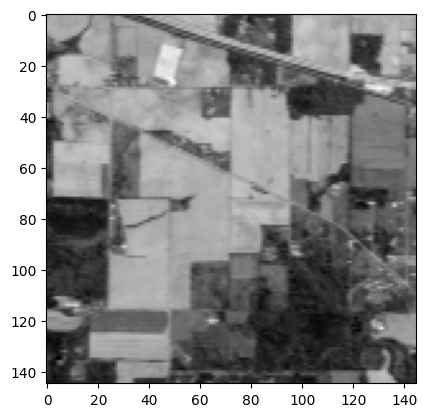

In [178]:
 
im = final_features["NP"]
plt.imshow(im, cmap="gray")
plt.show()

## Previous logic

In [131]:
WINDOW_SIZE = 25
import time
from sklearn.base import clone
from sklearn.metrics import cohen_kappa_score

classifier_mapping = {
    'SVM': SVC(kernel='rbf'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'RF': RandomForestClassifier(n_estimators=100, random_state=42),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=42)
}

if TARGET_CLF_FOR_OPTIMIZATION not in classifier_mapping:
    print(f"Warning: {TARGET_CLF_FOR_OPTIMIZATION} not recognized. Using 'ExtraTrees' instead.")
    TARGET_CLF_FOR_OPTIMIZATION = 'ExtraTrees'

metrics_data = []

for method, cube in final_features.items():
    print(f'\n--- Processing {method} with 25x25 Patches ---')

    patches, patch_labels = createImageCubes(cube, y, windowSize=WINDOW_SIZE, removeZeroLabels=True)
    X_flat = patches.reshape(patches.shape[0], -1)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    clf_name = TARGET_CLF_FOR_OPTIMIZATION

    print(f'  Evaluating {clf_name} (only this classifier)...')

    oa_scores = []
    aa_scores = []
    kappa_scores = []
    train_times = []
    test_times = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_flat, patch_labels)):
        X_train, X_test = X_flat[train_idx], X_flat[test_idx]
        y_train, y_test = patch_labels[train_idx], patch_labels[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        clf = clone(classifier_mapping[clf_name])

        start_train = time.time()
        clf.fit(X_train, y_train)
        train_times.append(time.time() - start_train)

        start_test = time.time()
        y_pred = clf.predict(X_test)
        test_times.append(time.time() - start_test)

        oa = accuracy_score(y_test, y_pred)
        aa = calculate_AA(y_test, y_pred)
        kappa = cohen_kappa_score(y_test, y_pred)

        print(f'    Fold {fold+1}: OA = {oa*100:.2f}%, AA = {aa*100:.2f}%, Kappa = {kappa:.4f}')

        oa_scores.append(oa)
        aa_scores.append(aa)
        kappa_scores.append(kappa)

    mean_oa = np.mean(oa_scores) * 100
    std_oa = np.std(oa_scores, ddof=1) * 100
    mean_aa = np.mean(aa_scores) * 100
    std_aa = np.std(aa_scores, ddof=1) * 100
    mean_kappa = np.mean(kappa_scores)
    std_kappa = np.std(kappa_scores, ddof=1)
    mean_train_time = np.mean(train_times)
    mean_test_time = np.mean(test_times)

    metrics_data.append({
        'Metaheuristic': method,
        'Classifier': clf_name,
        'Overall Accuracy (OA %)': f'{mean_oa:.2f} ± {std_oa:.2f}',
        'Average Accuracy (AA %)': f'{mean_aa:.2f} ± {std_aa:.2f}',
        'Kappa': f'{mean_kappa:.4f} ± {std_kappa:.4f}',
        'Avg Train Time (s)': f'{mean_train_time:.4f}',
        'Avg Test Time (s)': f'{mean_test_time:.4f}'
    })


--- Processing NP with 25x25 Patches ---
  Evaluating ExtraTrees (only this classifier)...
    Fold 1: OA = 99.80%, AA = 99.53%, Kappa = 0.9978
    Fold 2: OA = 99.95%, AA = 99.31%, Kappa = 0.9994
    Fold 3: OA = 99.95%, AA = 99.95%, Kappa = 0.9994
    Fold 4: OA = 100.00%, AA = 100.00%, Kappa = 1.0000
    Fold 5: OA = 100.00%, AA = 100.00%, Kappa = 1.0000


HSI -> PCA(1) -> ExtraTree -> 99.5

# Result Print and save

In [89]:
print("\n" + "="*60)
print("📊 FINAL SUMMARY (Avg across 5 folds)")
print("="*60)
for item in metrics_data:
    print(f"\nMetaheuristic: {item['Metaheuristic']}")
    print(f"  Classifier: {item['Classifier']}")
    print(f"  OA: {item['Overall Accuracy (OA %)']}%")
    print(f"  AA: {item['Average Accuracy (AA %)']}%")
    print(f"  Kappa: {item['Kappa']}")
    print(f"  CV: {item['CV']}")
    print(f"  Avg Train Time: {item['Avg Train Time (s)']} s")
    print(f"  Avg Test Time: {item['Avg Test Time (s)']} s")

# Excel ফাইলে সেভ করা
df_results = pd.DataFrame(metrics_data)
df_results.to_excel(f'{dataset}_final_metrics_foldwise_{TARGET_CLF_FOR_OPTIMIZATION}.xlsx', index=False)
print(f"\n✅ Results saved to {dataset}_final_metrics_foldwise_{TARGET_CLF_FOR_OPTIMIZATION}.xlsx")


📊 FINAL SUMMARY (Avg across 5 folds)

Metaheuristic: PSO
  Classifier: ExtraTrees
  OA: 99.09%
  AA: 97.29%
  Kappa: 0.9897
  CV: 76.72%
  Avg Train Time: 1.6983 s
  Avg Test Time: 0.5089 s

Metaheuristic: GWO
  Classifier: ExtraTrees
  OA: 98.77%
  AA: 96.45%
  Kappa: 0.9860
  CV: 75.80%
  Avg Train Time: 1.5100 s
  Avg Test Time: 0.2063 s

Metaheuristic: MFO
  Classifier: ExtraTrees
  OA: 99.01%
  AA: 96.44%
  Kappa: 0.9887
  CV: 78.21%
  Avg Train Time: 1.5479 s
  Avg Test Time: 0.2154 s

Metaheuristic: GA
  Classifier: ExtraTrees
  OA: 98.48%
  AA: 94.84%
  Kappa: 0.9827
  CV: 75.48%
  Avg Train Time: 1.5844 s
  Avg Test Time: 0.2037 s

✅ Results saved to IP_final_metrics_foldwise_ExtraTrees.xlsx
